## MP4 - TAMs proinflammatory subppopulation DEA

MP4 (Healthy-derived) scoring revealed what looks like two subpopulations within TAMs proinflammatory. \
This script: \
    1. subsets to Healthy cells only, cell type = TAMs proinflammatrory \
    2. splits those cells by HIHA_MP4_score at a threshold of 1.0 (>= 1.0 = "MP4_high", < 1.0 = "MP4_low") \
    3. runs a Wilcoxon DEG test between the two groups
 
Method: sc.tl.rank_genes_groups, Wilcoxon rank-sum test, use_raw=False - same convention used for DEG comparisons elsewhere in this project.

In [2]:
import os
os.environ['TZ'] = 'Europe/Berlin'
 
import re
 
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import gseapy as gp

In [3]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
mp_scores = pd.read_csv(f"{BASE}/results/09_HIHAtlas/09_03_nmf_downsampled/mp_scores_healthy.csv", index_col=0)
adata = sc.read_h5ad(f"{BASE}/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad")
print("Loaded:", adata.shape)
print(adata.obs.columns.tolist())
print("Loaded original NMF scores:", mp_scores.shape, mp_scores.columns.tolist())


Loaded: (208945, 22586)
['donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score', 'dataset', 'dataset_batch']
Loaded original NMF scores: (129435, 8) ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score']


In [5]:
mp_scores.head(10)

,MP1_score,MP2_score,MP3_score,MP4_score,MP5_score,MP6_score,MP7_score,MP8_score
barcodes,,,,,,,,
74fc381648b611eabab7c676ab45cfca,-0.090854,-0.523981,-0.531879,-0.093201,0.566022,-0.616668,-0.166547,0.199721
5cfdece648b111ea8fbed2ddb8e0a14a,-0.138964,-0.376928,-0.471963,-0.092312,0.602548,-0.650284,-0.145765,0.216961
6cfb85c848b511ea87c666a4322bd84a,-0.036029,-0.479844,-0.592716,-0.044581,0.614911,-0.633519,-0.159706,0.226616
54b6da1e495311ea86cade558b2f8879,-0.292412,-0.537504,-0.638312,-0.146883,1.129584,-0.623997,-0.142083,0.142925
54cdf6ae495311ea86cade558b2f8879,0.160440,-0.489670,-0.583046,-0.104478,0.194279,-0.620163,-0.181035,0.281437
deed398c48cf11eaacaa42cd98cbd24e,0.087413,-0.324105,-0.395248,-0.116565,0.396212,-0.571174,-0.099980,0.224932
def10a2648cf11eaacaa42cd98cbd24e,0.052091,-0.434396,-0.589313,-0.088747,0.461352,-0.608794,-0.162717,0.255518
70d4325c48b611eaa65d9e7d578d66f2,0.069879,-0.596430,-0.472956,-0.112867,0.164265,-0.647771,-0.111103,0.249194
c680bf5c48bd11eab2ee7a6edf799b61,-0.147246,-0.397147,-0.581725,-0.086223,0.964112,-0.610148,-0.097280,0.228602


In [6]:
if "condition" in adata.obs.columns:
    condition_col = "condition"
elif "dataset" in adata.obs.columns:
    label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
    adata.obs["condition"] = adata.obs["dataset"].map(label_map)
    condition_col = "condition"
else:
    raise ValueError(
        "Neither 'condition' nor 'dataset' found in adata.obs. Inspect "
        "obs columns and set the grouping column manually."
    )
print(f"Using condition column: '{condition_col}'")

Using condition column: 'condition'


In [7]:
print("Loaded original NMF scores:", mp_scores.shape, mp_scores.columns.tolist())
 
score_cols_native = [c for c in mp_scores.columns if re.match(r"MP\d+_score$", c)]
if not score_cols_native:
    raise ValueError(
        f"No MPX_score columns found in {mp_scores}. "
        f"Columns present: {mp_scores.columns.tolist()}"
    )
 

Loaded original NMF scores: (129435, 8) ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score']


In [8]:
healthy_mask = adata.obs[condition_col] == "Healthy"
print("Sample adata (Healthy) barcodes:", adata.obs_names[healthy_mask][:5].tolist())
print("Sample mp_scores_healthy.csv barcodes:", mp_scores.index[:5].tolist())

Sample adata (Healthy) barcodes: ['74fc381648b611eabab7c676ab45cfca-HIHAtlas', '5cfdece648b111ea8fbed2ddb8e0a14a-HIHAtlas', '6cfb85c848b511ea87c666a4322bd84a-HIHAtlas', '54b6da1e495311ea86cade558b2f8879-HIHAtlas', '54cdf6ae495311ea86cade558b2f8879-HIHAtlas']
Sample mp_scores_healthy.csv barcodes: ['74fc381648b611eabab7c676ab45cfca', '5cfdece648b111ea8fbed2ddb8e0a14a', '6cfb85c848b511ea87c666a4322bd84a', '54b6da1e495311ea86cade558b2f8879', '54cdf6ae495311ea86cade558b2f8879']


In [9]:
adata_barcodes_stripped = adata.obs_names.str.replace(r"-HIHAtlas$", "", regex=True)
 
aligned = mp_scores[score_cols_native].reindex(adata_barcodes_stripped)
aligned.index = adata.obs_names  # restore original index for assignment below
n_missing = aligned.isna().all(axis=1).sum()
print(f"{n_missing} of {adata.n_obs} cells in adata have no matching barcode in the original NMF scores after suffix-stripping (some non-Healthy/GBM cells are expected to not match at all, since mp_scores_healthy.csv only ever covered Healthy cells)")
 
for col in score_cols_native:
    adata.obs[col] = aligned[col].values

79510 of 208945 cells in adata have no matching barcode in the original NMF scores after suffix-stripping (some non-Healthy/GBM cells are expected to not match at all, since mp_scores_healthy.csv only ever covered Healthy cells)


In [10]:
# ---- 3. find the MP4 score column just merged in ----
mp4_candidates = [c for c in adata.obs.columns if re.match(r"(HIHA_)?MP4_score$", c)]
if not mp4_candidates:
    raise ValueError(
        f"No MP4 score column found after merging. Columns available: "
        f"{score_cols_native}"
    )
mp4_col = mp4_candidates[0]
print(f"Using MP4 score column: '{mp4_col}'")

Using MP4 score column: 'MP4_score'


In [11]:
healthy_TAMs  = adata[
    (adata.obs[condition_col] == "Healthy") & (adata.obs["decoupler_level1_celltype"] == "TAMs proinflammatory")
].copy()
print("Healthy TAMs proinflammatory subset shape (before dropping unscored cells):", healthy_TAMs.shape)
 
n_unscored = healthy_TAMs.obs[mp4_col].isna().sum()
if n_unscored:
    print(f"Dropping {n_unscored} of {healthy_TAMs.n_obs} Healthy TAMss with "
          f"no native MP4 score (not in the original NMF run)")
    healthy_TAMs = healthy_TAMs[healthy_TAMs.obs[mp4_col].notna()].copy()
 
print("Healthy TAMs subset shape (after dropping):", healthy_TAMs.shape)
print(healthy_TAMs.obs[mp4_col].describe())

Healthy TAMs proinflammatory subset shape (before dropping unscored cells): (1911, 22586)
Healthy TAMs subset shape (after dropping): (1911, 22586)
count    1911.000000
mean        1.026537
std         1.151943
min        -0.226354
25%        -0.092259
50%         0.245168
75%         2.168774
max         3.067509
Name: MP4_score, dtype: float64


In [12]:
THRESHOLD = 1.0
MIN_CELLS = 10


healthy_TAMs.obs["MP4_group"] = pd.Categorical(
    (healthy_TAMs.obs[mp4_col] >= THRESHOLD).map({True: "MP4_high", False: "MP4_low"}),
    categories=["MP4_low", "MP4_high"],
)
print(healthy_TAMs.obs["MP4_group"].value_counts())
 
n_low = (healthy_TAMs.obs["MP4_group"] == "MP4_low").sum()
n_high = (healthy_TAMs.obs["MP4_group"] == "MP4_high").sum()
if n_low < MIN_CELLS or n_high < MIN_CELLS:
    raise ValueError(
        f"One group has too few cells for a reliable DEG test "
        f"(MP4_low={n_low}, MP4_high={n_high}, MIN_CELLS={MIN_CELLS}). "
        f"Consider adjusting THRESHOLD."
    )

MP4_group
MP4_low     976
MP4_high    935
Name: count, dtype: int64


In [13]:
print(f"X.min()={healthy_TAMs.X.min():.3f}  X.max()={healthy_TAMs.X.max():.3f}  "
      f"log1p flag={healthy_TAMs.uns.get('log1p')}")

X.min()=0.000  X.max()=8.923  log1p flag=None


### DEG between MP4_high and MP4_low

In [14]:
sc.tl.rank_genes_groups(
    healthy_TAMs,
    groupby="MP4_group",
    groups=["MP4_high"],
    reference="MP4_low",
    method="wilcoxon",
    use_raw=False,
)
 
deg_df = sc.get.rank_genes_groups_df(healthy_TAMs, group="MP4_high")
out_csv = os.path.join(OUT_DIR, "10_09_deg_TAMs_MP4_high_vs_low.csv")
deg_df.to_csv(out_csv, index=False)
print(f"\nSaved DEG results to {out_csv}")
 
print("\nTop 20 genes (by score, sign: positive = up in MP4_high):")
print(deg_df.sort_values("scores", ascending=False).head(20).to_string(index=False))


Saved DEG results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_deg_TAMs_MP4_high_vs_low.csv

Top 20 genes (by score, sign: positive = up in MP4_high):
   names    scores  logfoldchanges         pvals     pvals_adj
    NRGN 37.698528        8.560927  0.000000e+00  0.000000e+00
     PF4 37.556507       10.422261 1.103213e-308 1.245859e-304
   TUBB1 37.499409       10.881203 9.416966e-308 5.729632e-304
  CAVIN2 37.497421        8.634539 1.014723e-307 5.729632e-304
   GNG11 37.486889       10.429204 1.506473e-307 6.805041e-304
    PPBP 37.450233       11.090998 5.954660e-307 2.241533e-303
    CCL5 37.420834        8.296469 1.791296e-306 5.779746e-303
  TAGLN2 36.579914        4.354663 5.967501e-293 1.684775e-289
  MYL12A 36.205315        3.719593 5.021432e-287 1.260156e-283
    OAZ1 36.090912        2.872656 3.149237e-285 6.466242e-282
     CLU 36.023739        8.331086 3.555689e-284 6.692399e-281
   H3-3A 35.701885        2.172593 3.69

In [13]:
print(deg_df.sort_values("scores", ascending=True).head(20).to_string(index=False))

 names     scores  logfoldchanges         pvals     pvals_adj
 RPS24 -36.167040       -5.177195 2.007970e-286 4.535202e-283
  RPS8 -35.879730       -5.399526 6.326611e-282 1.099176e-278
 RPL39 -35.875668       -4.809316 7.320442e-282 1.180996e-278
 RPL28 -35.809322       -4.749289 7.908133e-281 1.190754e-277
 RPS13 -35.557255       -4.966559 6.418775e-277 8.527909e-274
 RPL34 -35.514957       -4.813819 2.888739e-276 3.624726e-273
 RPS28 -35.467854       -4.857174 1.539369e-275 1.829904e-272
 RPS14 -35.463955       -4.708295 1.767771e-275 1.963844e-272
 RPL26 -35.463043       -5.237222 1.825942e-275 1.963844e-272
 RPL32 -35.443844       -4.780026 3.608490e-275 3.704607e-272
 RPL37 -35.389816       -4.896204 2.449242e-274 2.304940e-271
EEF1A1 -35.227978       -4.262097 7.460022e-272 6.480464e-269
 RPL13 -35.220512       -4.277153 9.705335e-272 8.118693e-269
 RPS23 -35.215908       -5.161694 1.141472e-271 9.207602e-269
 RPL30 -35.137540       -4.439377 1.801725e-270 1.403233e-267
  RPS2 -

### GSEA

In [5]:
deg_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_09_deg_TAMs_MP4_high_vs_low.csv")
print("Loaded DEG results:", deg_df.shape)


Loaded DEG results: (22586, 5)


In [6]:
# GENE_SETS = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/c7.immunesigdb.v2026.1.Hs.symbols.gmt" # immuneSigDB
GENE_SETS = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/c5.go.bp.v2026.1.Hs.symbols.gmt" # GO

GSEA_OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA/10_10_GSEA_TAMs_MP4"
os.makedirs(GSEA_OUT_DIR, exist_ok=True)

In [7]:
rnk = deg_df[["names", "scores"]].sort_values("scores", ascending=False)
rnk.columns = ["gene_name", "Wilcoxon score"]
rnk = rnk.drop_duplicates("gene_name").set_index("gene_name")
print(f"Ranked gene list: {len(rnk)} genes")

Ranked gene list: 22586 genes


In [8]:
pre_res = gp.prerank(
    rnk=rnk,
    gene_sets=GENE_SETS,
    min_size=5,
    max_size=1000,
    permutation_num=1000,
    outdir=os.path.join(GSEA_OUT_DIR, "10_10_prerank_TAMs_MP4_GO"),
    seed=42,
    threads=4,
)
 
res_df = pre_res.res2d.copy()
out_csv = os.path.join(GSEA_OUT_DIR, "10_10_gsea_prerank_TAMs_GO.csv")
res_df.to_csv(out_csv, index=False)
print(f"Saved full GSEA results to {out_csv}")

2026-09-25 17:44:12,749 [WARNING] Duplicated values found in preranked stats: 61.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Saved full GSEA results to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_10_GSEA_TAMs_MP4/10_10_gsea_prerank_TAMs_GO.csv


In [9]:

FDR_CUTOFF = 0.05

sig = res_df[res_df["FDR q-val"] < FDR_CUTOFF].copy()
print(f"{len(sig)} significant terms at FDR<{FDR_CUTOFF}")
 
if sig.empty:
    raise SystemExit("No significant GSEA terms found - nothing to plot.")
 
sig["NES"] = sig["NES"].astype(float)
sig = sig.sort_values("NES")

13 significant terms at FDR<0.05


In [10]:
TOP_N_PER_DIRECTION = 10
top_pos = sig[sig["NES"] > 0].sort_values("NES", ascending=False).head(TOP_N_PER_DIRECTION)
top_neg = sig[sig["NES"] < 0].sort_values("NES", ascending=True).head(TOP_N_PER_DIRECTION)
sig = pd.concat([top_neg, top_pos]).sort_values("NES")
print(f"Plotting top {len(top_pos)} positive + top {len(top_neg)} negative terms "
      f"(of {len(res_df[res_df['FDR q-val'] < FDR_CUTOFF])} significant total)")

Plotting top 7 positive + top 6 negative terms (of 13 significant total)


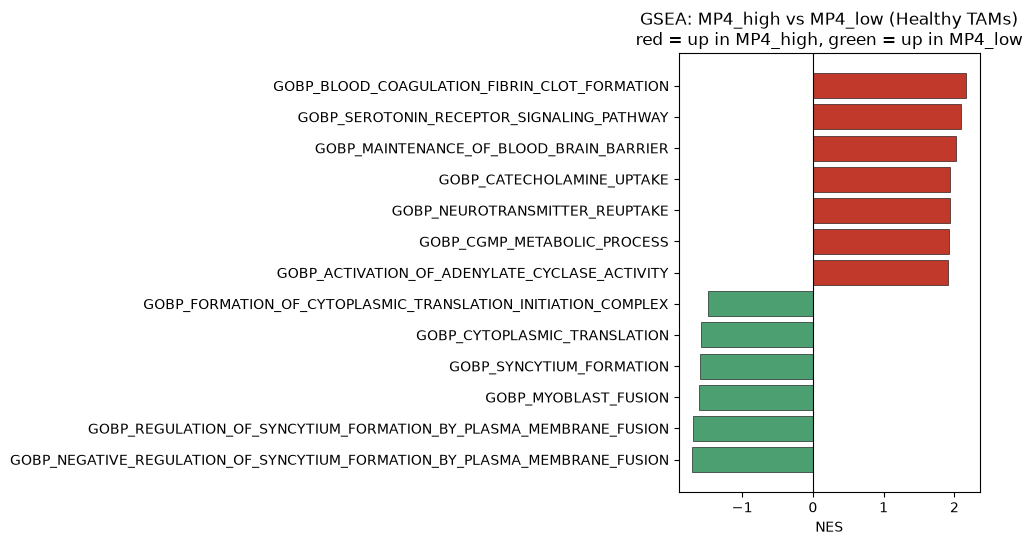

Saved barplot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_10_GSEA_TAMs_MP4/10_10_gsea_barplot_TAMs_MP4_GO.pdf


In [11]:
colors = sig["NES"].apply(lambda x: "#C0392B" if x > 0 else "#4C9F70")  # red = up in MP4_high, green = up in MP4_low
 
fig, ax = plt.subplots(figsize=(10, 0.35 * len(sig) + 1))
ax.barh(sig["Term"], sig["NES"], color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("NES")
ax.set_title("GSEA: MP4_high vs MP4_low (Healthy TAMs)\nred = up in MP4_high, green = up in MP4_low")
fig.tight_layout()
 
out_pdf = os.path.join(GSEA_OUT_DIR, "10_10_gsea_barplot_TAMs_MP4_GO.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"Saved barplot to {out_pdf}")
 

In [12]:
# GO TERMS

print("Top 10 by NES (positive direction, any significance):")
print(res_df.sort_values("NES", ascending=False).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

print("\nTop 10 by NES (negative direction, any significance):")
print(res_df.sort_values("NES", ascending=True).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

Top 10 by NES (positive direction, any significance):
                                                                        Term      NES  FDR q-val
                                GOBP_BLOOD_COAGULATION_FIBRIN_CLOT_FORMATION 2.167598   0.000000
                                   GOBP_SEROTONIN_RECEPTOR_SIGNALING_PATHWAY 2.094169   0.000961
                                     GOBP_MAINTENANCE_OF_BLOOD_BRAIN_BARRIER 2.018575   0.006405
                                                   GOBP_CATECHOLAMINE_UPTAKE 1.944038   0.021137
                                              GOBP_NEUROTRANSMITTER_REUPTAKE 1.933021   0.019984
                                                 GOBP_CGMP_METABOLIC_PROCESS 1.916755   0.021777
                               GOBP_ACTIVATION_OF_ADENYLATE_CYCLASE_ACTIVITY 1.909403   0.021961
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_IB 1.855210   0.052362
                                    GOBP_BLOOD_COAGULATION_INTRINSIC_PATH

In [ ]:
# print("Top 10 by NES (positive direction, any significance):")
# print(res_df.sort_values("NES", ascending=False).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

# print("\nTop 10 by NES (negative direction, any significance):")
# print(res_df.sort_values("NES", ascending=True).head(10)[["Term", "NES", "FDR q-val"]].to_string(index=False))

Top 10 by NES (positive direction, any significance):
                                                             Term      NES  FDR q-val
                                   GSE45365_BCELL_VS_CD8_TCELL_DN 1.706723        0.0
GSE37532_VISCERAL_ADIPOSE_TISSUE_VS_LN_DERIVED_TCONV_CD4_TCELL_DN 1.431168        0.0
                      GSE18791_UNSTIM_VS_NEWCATSLE_VIRUS_DC_1H_UP 1.000000        1.0
        GSE41867_DAY6_VS_DAY15_LCMV_CLONE13_EFFECTOR_CD8_TCELL_UP 1.000000        1.0
             GSE41176_UNSTIM_VS_ANTI_IGM_STIM_TAK1_KO_BCELL_3H_DN 1.000000        1.0
                                 GSE30083_SP2_VS_SP4_THYMOCYTE_UP 1.000000        1.0
            GSE18281_CORTICAL_THYMOCYTE_VS_WHOLE_CORTEX_THYMUS_UP 1.000000        1.0
                          GSE29618_PRE_VS_DAY7_FLU_VACCINE_PDC_UP 1.000000        1.0
                                  GSE11818_WT_VS_DICER_KO_TREG_UP 1.000000        1.0
                   GSE29615_DAY3_VS_DAY7_LAIV_FLU_VACCINE_PBMC_UP 1.000000        1.0
